Número de docs cargados: 4
Preview contenido: Carga de datos 
 
Este proceso permite agregar en la liquidación de sueldos del trabajador, valores 
Metadata: {'producer': 'Microsoft® Word para Microsoft 365', 'creator': 'Microsoft® Word para Microsoft 365', 'creationdate': '2022-08-29T22:01:31-04:00', 'author': 'Juan Carlos Rojas Banda', 'moddate': '2022-08-29T22:01:31-04:00', 'source': 'carga.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}
Tokens en el documento completo: 854


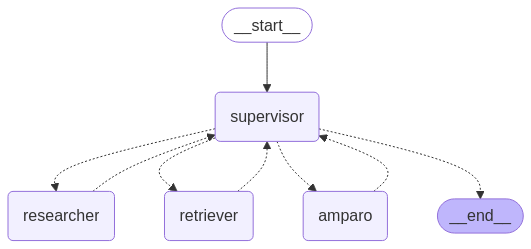

In [1]:
# Importación de librerias
# LangGraph
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

# LangChain
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools.retriever import create_retriever_tool
from langchain.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
# Utilidades
from typing import TypedDict, Optional, Dict, List, Literal, Annotated
from dotenv import load_dotenv, find_dotenv
import tiktoken
from IPython.display import Image, display
from sympy import content
from twisted.conch.ssh.connection import messages

# Carga de variables de entorno
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)
def count_tokens_in_docs(docs, model_name="gpt-4o"):
    """
    Calcula la cantidad total de tokens para una lista de documentos
    usando la librería tiktoken.

    :param docs: Lista de documentos (por ejemplo, la salida de un loader PDF).
    :param model_name: Nombre del modelo para el que queremos simular el conteo.
    :return: Número total de tokens en el contenido de los documentos.
    """
    # Obtenemos la codificación que usa el modelo seleccionado
    encoding = tiktoken.encoding_for_model(model_name)

    total_tokens = 0
    for doc in docs:
        # doc.page_content es el texto de cada página/documento
        text = doc.page_content
        total_tokens += len(encoding.encode(text))

    return total_tokens

# 2. CARGA DEL PDF
# ----------------------------------------------------------------------------
file_path = "carga.pdf"
loader = PyPDFLoader(file_path)
docs = loader.load()

# Cantidad de documentos extraídos (páginas, secciones, etc. según PyPDFLoader)
print("Número de docs cargados:", len(docs))

# Opcional: vista previa de los primeros 100 caracteres de la primera página
print("Preview contenido:", docs[0].page_content[0:100])
print("Metadata:", docs[0].metadata)

# 3. CONTAR TOKENS ANTES DE HACER NADA
# ----------------------------------------------------------------------------
tokens_en_documento = count_tokens_in_docs(docs, model_name="gpt-4o")
print("Tokens en el documento completo:", tokens_en_documento)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)
splits = text_splitter.split_documents(docs)

# Crea los embeddings
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(splits, embeddings)

# Crea el retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Modelo utilizado
llm = ChatOpenAI(model="gpt-4o")

# Creación del estado
class GlobalState(TypedDict): # Estado Globa
    graph: str
    messages: list[dict] # Es una lista de diccionarios
    next: str
    
class SearchState(TypedDict):
    search: List[dict]
    

# Miembros del equipo
members = ["researcher", "retriever", "amparo"]
options = members + ["FINISH"]

# Router con opciones para el llm
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["researcher", "retriever","amparo",  "FINISH"]
    
# Definir un nodo info o agent principal
system_prompt_amparo = "Eres Amparo un asistente virtual creado para apoyar al depto de rrhh de la empresa consstructora del mar. Tu trabajo consiste en responder a las solicitudes de los usuarios"
"""
Este nodo permitirá que el usuario interactue de una manera más natural con el sistema multiagente
"""

info_agent = create_react_agent(
    llm,
    tools=[],
    prompt=ChatPromptTemplate.from_messages([
        ("system", system_prompt_amparo),
        ("human", "{messages}")
    ])
)

def amparo(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = info_agent.invoke(state)
    print("Este es el tipo de RESULT", type(result))
    for a in result["messages"]:
        a.pretty_print()
    print("AMPARO")
    return Command(
        goto="supervisor",
        update={"messages": [
                AIMessage(content=result["messages"][-1].content)]},
    )

system_prompt = (
    "Tu nombre es Amparo, un asistente virtual que apoya las gestiones en el área de Recursos Humanos "
    "de la empresa Constructora del Mar II. Tu función principal es gestionar las solicitudes del usuario "
    f"derivándolas a los siguientes agentes especializados: {members}.\n"
    "El agente especializado 'researcher' se encarga de realizar búsquedas de información en la web.\n"
    "El agente especializado 'retriever' se encarga de recuperar información desde un documento llamado 'Carga de Datos', el cual ayuda con el uso de Unyrem, un módulo de Unysoft. "
    "Este documento contiene instrucciones sobre cómo cargar información en el módulo UnyRem del ERP Unysoft."
    "El agente especializado 'amparo' se encarga de las preguntsa generales, como quien eres o que funciones tienes.\n"
    "Tu tarea es analizar la pregunta del usuario y decidir cuál agente debe actuar en función de la solicitud.\n"
    "Selecciona el agente más apropiado para responder o investigar.\n"
    "En base al siguiente mensaje debes análizar si es una solicitud de usuario (deriva a unos de los agentes especialiados antes mencionados) o si es una respuesta de algunos de los agentes especializados debes responder con FINISH"
)

def supervisor_node(state: GlobalState) -> Command[Literal["researcher", "retriever","amparo", "__end__"]]:
    """user_input = state["messages"][-1]["content"]
    intent = classify_intent(user_input)    
    print("intent: ", intent)
    if intent[0] == "info":
        print("INTENT DEBUG tipo de mensaje:", type(state["messages"][-1]))
        # response = llm.with_structured_output(intent).invoke(state)
        goto = "amparo"
    else:
        print(" SUPERVISOR DEBUG tipo de mensaje:", type(state["messages"][-1]))
        print(state["messages"])"""
    for a in state["messages"]:
        print(a)
    messages = [{"role":"system", "content":system_prompt},] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    print("DIRIGIENDO FLUJO A: ", goto)
    print("SUPERVISOR")
    if goto == "FINISH":
        goto = END
    
    return Command(goto=goto, update = {"next":goto})

# Tool de search node 
tavily_tool = TavilySearchResults(max_results=1)
research_agent = create_react_agent(
    llm, tools=[tavily_tool], prompt="Eres un agente especializado en busqueda web."
)

def search_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    # print("DEBUG result: ", result)  # <-- esto
    print("Este es el tipo de RESULT", type(result))

    return Command(goto="supervisor", 
                   update = {
                       "__state__": {"search":result["messages"]},"messages":result["messages"]})


# Crea una herramienta a partir del retriever
retriever_tool = create_retriever_tool(
    retriever,
    name="reglamento_retriever",
    description="Busca información manual de Unyrem de Unysoft."
)

# Crea el agente con la herramienta
retriever_agent = create_react_agent(
    llm,
    tools=[retriever_tool],
    prompt="Eres un agente experto en responder preguntas sobre el manual de carga de datos al módulo UnyRem del sistema Unysoft,"
)

def retriever_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = retriever_agent.invoke(state)
    print("Este es el tipo de RESULT", type(result))
    
    return Command(
        goto="supervisor",
        update={
            "messages": result["messages"]
        }
    )
builder = StateGraph(GlobalState)
builder.add_edge(START, "supervisor")
builder.add_node("amparo", amparo)
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher",search_node)
builder.add_node("retriever",retriever_node)

graph =  builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [40]:
sal = graph.invoke({"messages": ["¿Como se llama el presidente de eeuu de  2024?"]})
for m in sal["messages"]:
    m.pretty_print()

¿Como se llama el presidente de eeuu de  2024?
DIRIGIENDO FLUJO A:  researcher
SUPERVISOR
Este es el tipo de RESULT <class 'langgraph.pregel.io.AddableValuesDict'>
content='¿Como se llama el presidente de eeuu de  2024?' additional_kwargs={} response_metadata={} id='27f5e21f-419d-4db3-849b-1366a8503fb1'
content='' additional_kwargs={'tool_calls': [{'id': 'call_UNlcdd9ehlkvwA9oI6jma2iO', 'function': {'arguments': '{"query":"presidente de Estados Unidos 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 104, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7e8d90e604', 'id': 'chatcmpl-BFRZtyAyN89tlaZroB5mjVpy313Yk', 'finish_reason': 'tool_cal

In [2]:
sal = graph.invoke({"messages": ["¿Como te llamas y cuales son tus funciones?"]})
for m in sal["messages"]:
    m.pretty_print()

¿Como te llamas y cuales son tus funciones?
DIRIGIENDO FLUJO A:  amparo
SUPERVISOR
Este es el tipo de RESULT <class 'langgraph.pregel.io.AddableValuesDict'>
================================ Human Message =================================

¿Como te llamas y cuales son tus funciones?
================================== Ai Message ==================================

Hola, soy Amparo, el asistente virtual del departamento de recursos humanos de la empresa Constructora del Mar. Mi función principal es apoyar a los empleados con sus consultas y solicitudes relacionadas con recursos humanos, tales como información sobre políticas de la empresa, beneficios, procedimientos de contratación y cualquier otra pregunta que pueda surgir en el entorno laboral. Estoy aquí para ayudarte en lo que necesites.
AMPARO
content='Hola, soy Amparo, el asistente virtual del departamento de recursos humanos de la empresa Constructora del Mar. Mi función principal es apoyar a los empleados con sus consultas y solic

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\Users\Luis Pizarro\anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Luis Pizarro\AppData\Local\Temp\ipykernel_14172\2447273671.py", line 1, in <module>
    sal = graph.invoke({"messages": ["¿Como te llamas y cuales son tus funciones?"]})
  File "C:\Users\Luis Pizarro\anaconda3\lib\site-packages\langgraph\pregel\__init__.py", line 2683, in invoke
    for chunk in self.stream(
  File "C:\Users\Luis Pizarro\anaconda3\lib\site-packages\langgraph\pregel\__init__.py", line 2331, in stream
    for _ in runner.tick(
  File "C:\Users\Luis Pizarro\anaconda3\lib\site-packages\langgraph\pregel\runner.py", line 146, in tick
    run_with_retry(
  File "C:\Users\Luis Pizarro\anaconda3\lib\site-packages\langgraph\pregel\retry.py", line 40, in run_with_retry
    return task.proc.invoke(task.input, config)
  File "C:\Users\Luis Pizarro\anaconda3\lib\si

TypeError: object of type 'NoneType' has no len()